# Исследование рынка компьютерных игр

В нашем распоряжении исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы (например, _Xbox_ или _PlayStation_). Необходимо выявить определяющие успешность игры закономерности. Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.

Имеются данные до 2016 года. Необходимо спланировать кампанию на 2017-й

Данные за 2016 год неполные.

В наборе данных попадается аббревиатура _ESRB (Entertainment Software Rating Board)_ — это ассоциация, определяющая возрастной рейтинг компьютерных игр. _ESRB_ оценивает игровой контент и присваивает ему подходящую возрастную категорию, например, «Для взрослых», «Для детей младшего возраста» или «Для подростков».

**Цель исследования:**
- Оценить рынок компьютерных игр, от чего зависят продажи
- Спланировать кампанию на следующий год

**Описание данных**

- _Name_ — название игры
- _Platform_ — платформа
- _Year_of_Release_ — год выпуска
- _Genre_ — жанр игры
- _NA_sales —_ продажи в Северной Америке (миллионы проданных копий)
- _EU_sales_ — продажи в Европе (миллионы проданных копий)
- _JP_sales_ — продажи в Японии (миллионы проданных копий)
- _Other_sales —_ продажи в других странах (миллионы проданных копий)
- _Critic_Score_ — оценка критиков (максимум 100)
- _User_Score_ — оценка пользователей (максимум 10)
- _Rating_ — рейтинг от организации _ESRB_ (англ. _Entertainment Software Rating Board)._ Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию.

## Открытие данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats as st
import warnings
warnings.filterwarnings('ignore')
plt.style.use('default')

In [2]:
games = pd.read_csv("games.csv")
display(games.head(15))
games.info()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


Предварительно в данных можно увидеть следующие проблемы:
- названия столбцов не в нижнем регистре
- есть пропуски

## Предобработка данных

### Замена названий столбцов

Приведём названия столбцов к нижнему регистру

In [3]:
games.columns = games.columns.str.lower()
games.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

### Преобразование типов данных

Столбец `user_score` можно было бы привести к типу `float`, но посмотрим сначала на значения этого столбца

In [4]:
games['user_score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

В этом столбце есть значения `tbd`, что расшифровывается как "To Be Determined" ("будет определено"). Будем считать такие значения как `NaN`

In [5]:
games.loc[games['user_score'] == 'tbd', 'user_score'] = np.nan

Приведём столбец `user_score` к типу `float`

In [6]:
games['user_score'] = games['user_score'].astype('float64')

### Обработка дубликатов

Найдём количество явных дубликатов

In [14]:
print(games.duplicated().sum())

0


Найдём количество неявных дубликатов в столбце `name`

In [16]:
print(games.duplicated(subset='name').sum())

5155


Выведем дубликаты по столбцу `name`

In [17]:
display(games[games.duplicated(subset='name')].head(10))

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
23,Grand Theft Auto V,X360,2013.0,Action,9.66,5.14,0.06,1.41,97.0,8.1,M
35,Call of Duty: Black Ops II,X360,2012.0,Shooter,8.25,4.24,0.07,1.12,83.0,4.8,M
37,Call of Duty: Modern Warfare 3,PS3,2011.0,Shooter,5.54,5.73,0.49,1.57,88.0,3.2,M
41,Call of Duty: Black Ops,PS3,2010.0,Shooter,5.99,4.37,0.48,1.79,88.0,6.4,M
42,Grand Theft Auto V,PS4,2014.0,Action,3.96,6.31,0.38,1.97,97.0,8.3,M
55,Call of Duty: Modern Warfare 2,PS3,2009.0,Shooter,4.99,3.64,0.38,1.60,94.0,6.3,M
57,Grand Theft Auto IV,PS3,2008.0,Action,4.76,3.69,0.44,1.61,98.0,7.5,M
59,Super Mario 64,DS,2004.0,Platform,5.01,3.07,1.25,0.97,NaN,NaN,NaN
69,Call of Duty: Ghosts,PS3,2013.0,Shooter,4.10,3.63,0.38,1.25,71.0,2.6,M
99,Call of Duty: Black Ops 3,XOne,2015.0,Shooter,4.59,2.11,0.01,0.68,NaN,NaN,NaN


Выведем строки с именем `Grand Theft Auto V`

In [18]:
games[games['name'] == 'Grand Theft Auto V']#games[games.duplicated(subset='name')].head(1)['name']

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
16,Grand Theft Auto V,PS3,2013.0,Action,7.02,9.09,0.98,3.96,97.0,8.2,M
23,Grand Theft Auto V,X360,2013.0,Action,9.66,5.14,0.06,1.41,97.0,8.1,M
42,Grand Theft Auto V,PS4,2014.0,Action,3.96,6.31,0.38,1.97,97.0,8.3,M
165,Grand Theft Auto V,XOne,2014.0,Action,2.81,2.19,0.00,0.47,97.0,7.9,M
1730,Grand Theft Auto V,PC,2015.0,Action,0.39,0.69,0.00,0.09,96.0,7.9,M


В данном случае дубликатами являются версии одной одной и той же игры, выпущенной под разные платформы. Не будем считать данный случай за дубликаты.

Выведем кол-во пропусков в `name`

In [19]:
print(games[games['name'].isna()]['platform'].count())

2


Выведем эти строки

In [20]:
games[games['name'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


В этих же 2 строках пропуски в поле `genre`

Удалим эти строки

In [21]:
games = games.dropna(subset=['name'])

Приведём все названия игр к нижнему регистру

In [22]:
games['name'] = games['name'].str.lower()

Также при беглом просмотре можно увидеть строки в которых в имени игры есть уточнение в скобках

In [23]:
games[games['name'].str.contains(r"\(")]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
87,star wars battlefront (2015),PS4,2015.0,Shooter,2.99,3.49,0.22,1.28,NaN,NaN,NaN
342,star wars battlefront (2015),XOne,2015.0,Shooter,2.04,1.28,0.02,0.32,NaN,NaN,NaN
416,gran turismo (psp),PSP,2009.0,Racing,0.50,1.58,0.31,0.87,NaN,NaN,NaN
603,ghostbusters: the video game (ds version),X360,2009.0,Action,1.04,1.22,0.03,0.27,NaN,NaN,NaN
639,need for speed (2015),PS4,2015.0,Racing,0.50,1.50,0.05,0.37,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16602,"transformers: war for cybertron (xbox 360, ps3...",PC,2010.0,Shooter,0.01,0.00,0.00,0.00,NaN,NaN,NaN
16616,national geographic panda (jp sales),DS,2008.0,Simulation,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16631,the amazing spider-man 2 (2014),PC,2014.0,Action,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16656,imagine figure skater (jp sales),DS,2007.0,Sports,0.00,0.00,0.01,0.00,NaN,NaN,NaN


Выведем все уникальные уточнения

In [24]:
games[games['name'].str.contains(r'\(')]['name'].str.extract(r'\((.*?)\)')[0].unique()

array(['2015', 'psp', 'ds version', '2013', 'jp weekly sales',
       'all region sales', '2010', 'old all region sales', '2016',
       'weekly american sales', 'remake', 'japan', 'america weekly sales',
       'jp & others sales', 'american and others sales',
       'us weekly sales', 'xbox 360, ps2, ps3, wii & pc versions', '2014',
       '2012', 'console version', 'xbox 360, ps3, & pc versions',
       'others sales', 'us & others sales', 'rp-t', '2008',
       'old us sales', 'us sales', 'jp version', 'jp sales', 'rp-m',
       'wii & ps2 version', 'all regions sales', 'codemasters', 'gbc',
       '2006', 'ds versions', '2009', 'koei', 'weekly jp sales', 'jp',
       'cd', 'higher jp sales', 'jp & incomplete us sales',
       'american sales', 'online edition', 'north america',
       'sales, but wrong system', 'insomniac', 'red',
       'ps1 & psp versions', 'joukan', '3ds', 'ebkore+', 'telltale',
       'japan sales', '8-bit', 'correct us sales', 'pal', 'old jp sales',
       'r

Можно выделить следующие виды уточнений:
- Год. Вероятнее всего это ремастеры игры, будем считать их как отдельные игры.
- Платформа. Это просто указание платформы. В рамках данного исследования такие уточнения бессмыслены (платформа указывается в отдельном столбце) однако не приносят вреда, следовательно оставляем без изменений.
- Строки содержащие слово `sales`. Вероятно это продажи в отдельном регионе, по какой-то причине вынесенные в отдельную строку. Такие строки будем объединять со строками без уточнений. 
- Всё остальное. Нужно рассматривать каждое в отдельности. Даже если и является дубликатом, количество незначительно.

In [25]:
games.loc[games['name'].str.contains('sales'), 'name'] = games['name'].str.replace(r'\([^)]*\)', '', regex=True).str.strip()

Теперь объединим строки в которых были "sales-уточнения" со строками без них, проверяя что `platform` одная и та же, в полях `year_of_release`, `genre`, `critic_score`, `user_score`, `rating` будем оставлять первое значение, в остальных суммировать

In [30]:
#объединим дубликаты в отдельном датафрейме
new_names = games[games.duplicated(['name','platform'], keep=False)].groupby(['name','platform']).agg({
    'year_of_release'   : 'first',
    'genre'             : 'first',
    'na_sales'          : 'sum',
    'eu_sales'          : 'sum',
    'jp_sales'          : 'sum',
    'other_sales'       : 'sum',
    'critic_score'      : 'first',
    'user_score'      : 'first',
    'rating'            : 'first'
}).reset_index()

#удалим дубликаты
games = games.drop_duplicates(subset=['name', 'platform'], keep=False)

#добавляем строки с объединёнными дубликатами
games = pd.concat([games, new_names], ignore_index=True, sort=False)

### Обработка пропусков

Выведем кол-во пропусков в каждом столбце

In [31]:
games.isna().sum()

name                  0
platform              0
year_of_release     263
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8419
user_score         8965
rating             6615
dtype: int64

Строки с пропусками в столбце `year_of_release` удалим т.к. нам важны эти значения в рамках данного исследования

In [32]:
games = games.dropna(subset=['year_of_release'])

Приведём данные с столбец `year_of_release` к типу `int`

In [33]:
games['year_of_release'] = games['year_of_release'].astype('int64')

В столбцах `critic_score` и `user_score` очень много пропусков. Это может быть вызвано тем, что на источнике из которого брались данные нет оценок старых или непопулярных игр. Заменять их ни на что не будем т.к. при таком большом количестве это внесёт искажения.

Столбцы `year_of_release` и `rating` заполнять не будем т.к. это категориальные значения

Причиной возникновения пропусков может служить неполнота или утрата информации (на старые игры могли не писать рецензий или они не сохранились) или технические ошибки

In [34]:
games.isna().sum()

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8309
user_score         8828
rating             6532
dtype: int64

### Рассчёт суммарных продаж во всех регионах

In [35]:
games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']

In [36]:
games.head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,wii sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,super mario bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,mario kart wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,wii sports resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,pokemon red/pokemon blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38
5,tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN,30.26
6,new super mario bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80
7,wii play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91
8,new super mario bros. wii,Wii,2009,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E,28.32
9,duck hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN,28.31


### Вывод

В таблице `games` присутствует пропуски во многих столбцах. Они могут быть вызваны неполнотой или утратой информации (на старые игры могли не писать рецензий, или они не сохранились) или технической ошибкой.

Что было сделано:
- Названия столбцов приведены к нижнему регистру
- В столбце `user_score` значения `tbd` ("To Be Determined") были заменены на `NaN`
- Тип данных в столбце `user_score` изменён на `float`
- Удалены строки с пропусками в столбцах `name` и `genre`
- Обработана неявные дубликаты в столбце `name`
- Создан столбец `total_sales` с суммарными продажами во всех регионах

## Исследовательский анализ данных

### Анализ продаж по годам

Посмотрим как менялось количество проданых игр с течением лет

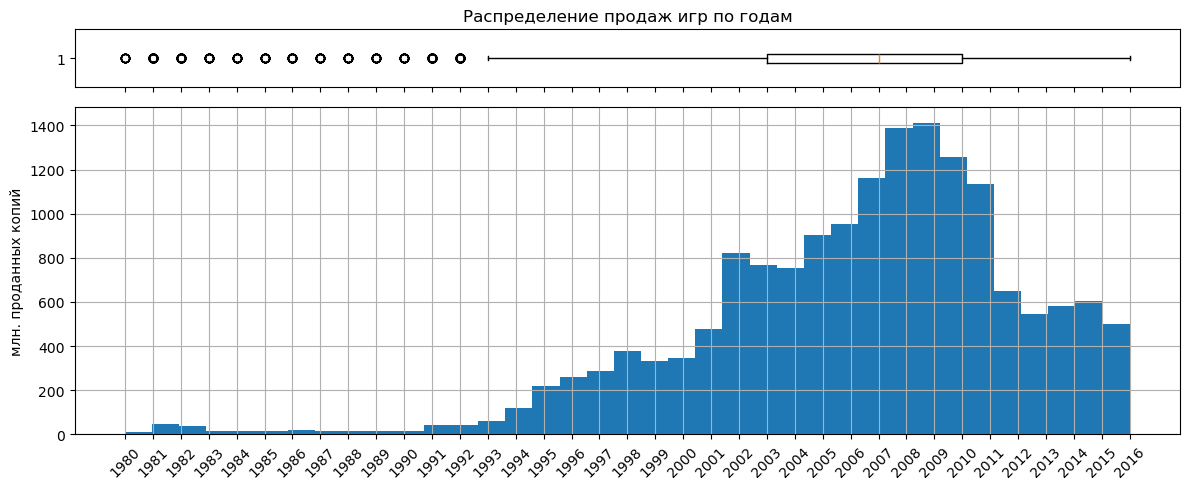

In [37]:
fig, axes = plt.subplots(ncols=1, nrows=2, gridspec_kw={'height_ratios' : [15, 85]}, figsize=(12, 5), sharex=True)
axes[0].boxplot(games['year_of_release'], vert=False)
axes[0].set_title('Распределение продаж игр по годам')

axes[1].hist(games['year_of_release'], bins=games['year_of_release'].max() - games['year_of_release'].min() + 1)
axes[1].set_xticks(range(1980, 2017))
axes[1].set_xticklabels(range(1980, 2017), rotation=45)
axes[1].grid()
axes[1].set_ylabel('млн. проданных копий')

plt.tight_layout()
plt.show()

По построеному графику можно сказать, что большая часть игр выпускалась после 1993, следовательно игры, выпущенные до учитывать не будем

In [38]:
games = games.query('year_of_release > 1993')

### Анализ платформ

Сгруппируем продажи по платформам и вычислим продолжительность жизни платформы

In [39]:
platforms = games.pivot_table(
    index='platform',
    aggfunc={'total_sales':'sum', 'year_of_release':['min', 'max']})#.sort_values(by='total_sales', ascending=False).head(10)
platforms.columns=['total_sales', 'year_last','year_first']
platforms['lifespan'] = platforms['year_last'] - platforms['year_first'] + 1
platforms

,total_sales,year_last,year_first,lifespan
platform,,,,
3DO,0.10,1995,1994,2
3DS,257.81,2016,2011,6
DC,15.95,2008,1998,11
DS,791.74,2013,2004,10
GB,152.08,2001,1994,8
GBA,306.23,2007,2000,8
GC,195.31,2007,2001,7
GEN,8.13,1994,1994,1
N64,215.51,2002,1996,7


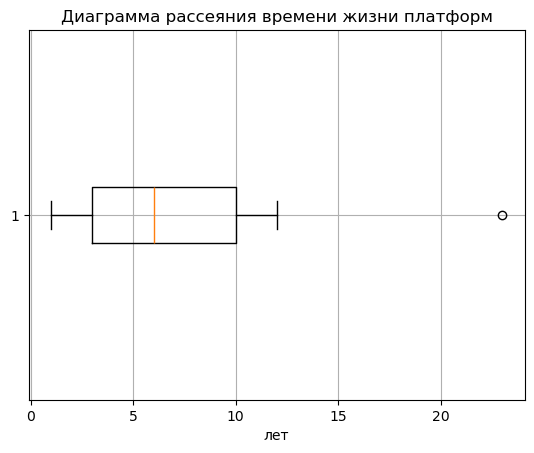

count    29.000000
mean      6.931034
std       4.876555
min       1.000000
25%       3.000000
50%       6.000000
75%      10.000000
max      23.000000
Name: lifespan, dtype: float64

In [40]:
plt.boxplot(platforms['lifespan'], vert=False)
plt.title('Диаграмма рассеяния времени жизни платформ')
plt.xlabel('лет')
plt.grid()
plt.show()
platforms['lifespan'].describe().T

По графику можно сказать, что мелианное время жизни платформы 6 лет, а межквартильный размах находится между 3 и 10 годами

Построим график продаж игр на различных платформах по годам c 2013 с учётом что на эти платформы ещё выходили игры в 2015 (не берём 2016 т.к. данные за него не полные)

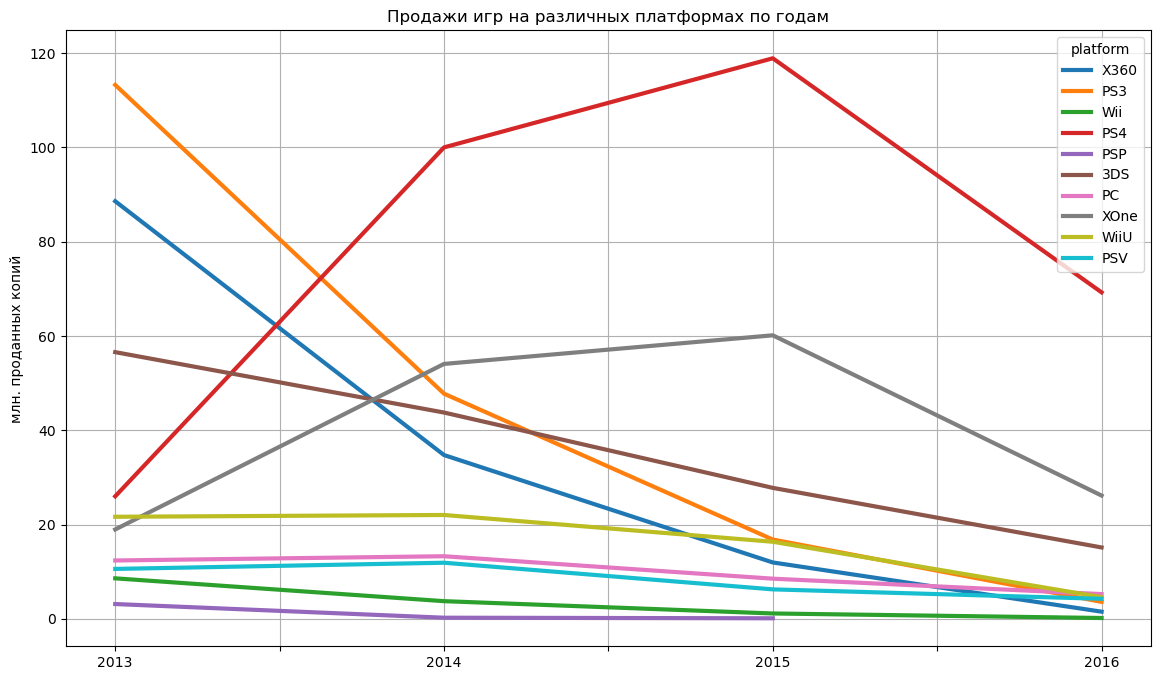

In [41]:
top_platforms_list = platforms.query('year_last >= 2015').sort_values(by='total_sales', ascending=False).index
top_selling_platforms = games.query('year_of_release > 2012').pivot_table(
    index='platform',
    columns='year_of_release',
    aggfunc={'total_sales':'sum'}).loc[top_platforms_list]
top_selling_platforms.columns = ['2013', '2014', '2015', '2016']
top_selling_platforms.T.plot(figsize=(14,8), grid=True, linewidth=3)
plt.title('Продажи игр на различных платформах по годам')
plt.ylabel('млн. проданных копий')
plt.xlabel('')
plt.show()

Спад в 2016 году объясняется неполнотой данных за этот год. Как перспективные платформы можно в первую очередь отметить консоли нового поколения PS4 и XOne. Среди консолей старого поколения больше всего продаж у 3DS, PS3, WiiU и X360

Рассмотрим распределение продаж игр на различных платформах за актуальный период (последние 5 лет)

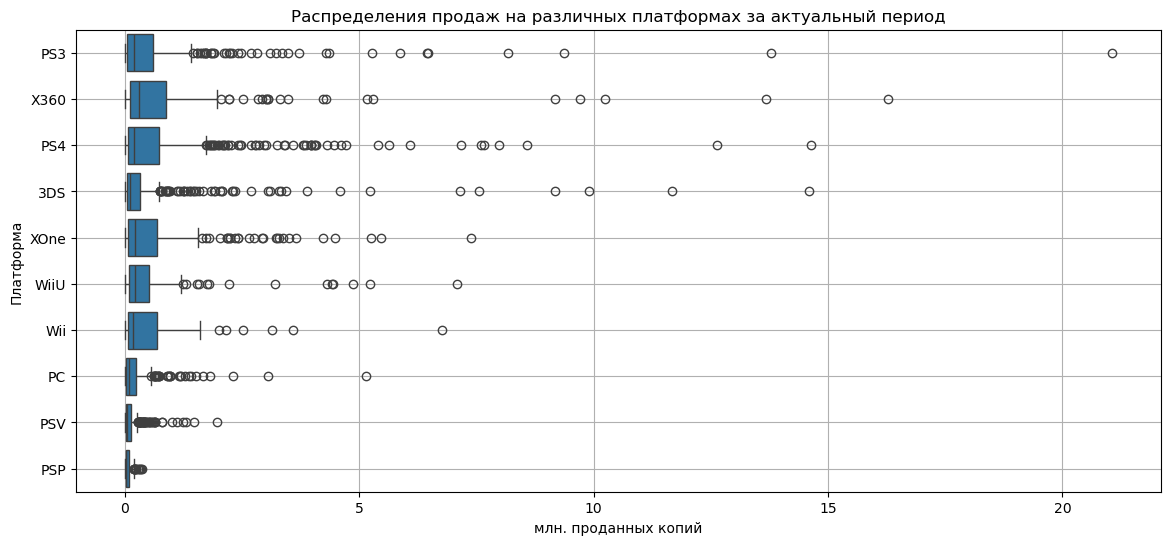

In [42]:
games_latest = games.query('year_of_release >= 2012 and platform in @top_platforms_list')
plt.figure(figsize=(14,6))
sns.boxplot(x=games_latest['total_sales'], y=games_latest['platform'])
plt.title('Распределения продаж на различных платформах за актуальный период')
plt.xlabel('млн. проданных копий')
plt.ylabel('Платформа')
plt.grid()

На диаграммах видны очень большие выбросы, однако они объясняются популярностью некоторых игр, именно на них магазину следует делать упор. Меньше всего таких выбросов у PSV и PSP, больше всего у консолей нынешнего поколения (PS3 и X360), однако консоли нового поколения (PS4 и XOne) активно нагоняют.

Рассмотрим левые части диаграмм размаха поближе

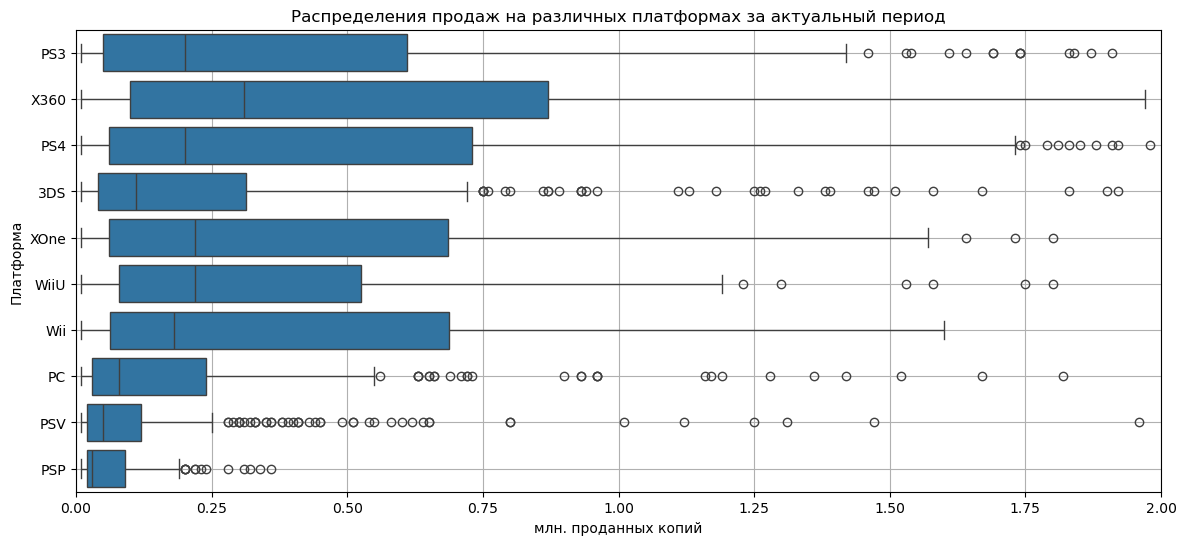

In [43]:
plt.figure(figsize=(14,6))
sns.boxplot(x=games_latest['total_sales'], y=games_latest['platform'])
plt.title('Распределения продаж на различных платформах за актуальный период')
plt.xlabel('млн. проданных копий')
plt.ylabel('Платформа')
plt.xlim(0, 2)
plt.grid()

По двум графиком можжно сделать следующие выводы.
Самые популярные платформы:
- По выбросам: `PS3`, `X360`, `PS4`, `3DS`
- По 75-ому процентилю: `X360`, `PS4`, `XOne/Wii`, `PS3`
- По медиане: `X360`, `XOne`, `WiiU`, `PS4/PS3`

Итого самые перспективные консоли, те, которые чаще всего встречаются в этом списке: `X360`, `PS3`, `PS4`, `XOne`

### Анализ оценок критиков и пользователей

Рассмотрим влияние оценок критиков и пользователей на продажи у более популярной платформы (PS4) и менее популярной (WiiU). Также отдельно рассмотрим PC

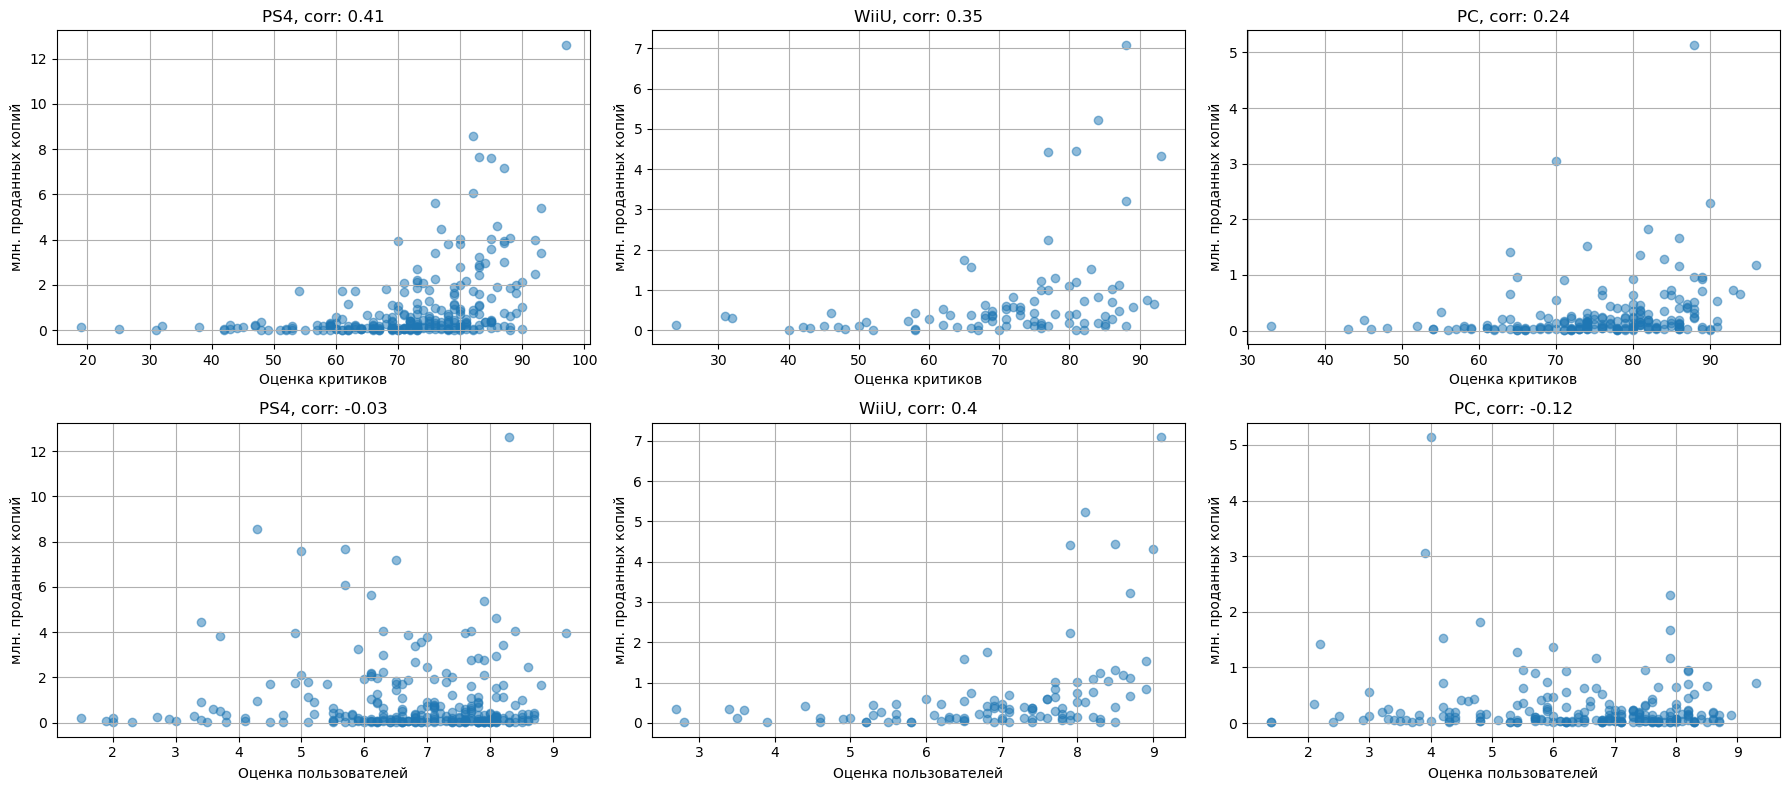

In [44]:
games_lates_ps4 = games_latest.query('platform == "PS4"')
games_lates_wiiu = games_latest.query('platform == "WiiU"')
games_lates_pc = games_latest.query('platform == "PC"')

fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(18,8))

axes[0, 0].scatter(games_lates_ps4['critic_score'], games_lates_ps4['total_sales'], alpha=0.5)
axes[0, 0].grid()
axes[0, 0].set_title(f'PS4, corr: {round(games_lates_ps4["critic_score"].corr(games_lates_ps4["total_sales"]),2)}')
axes[0, 0].set_xlabel('Оценка критиков')
axes[0, 0].set_ylabel('млн. проданных копий')

axes[1, 0].scatter(games_lates_ps4['user_score'], games_lates_ps4['total_sales'], alpha=0.5)
axes[1, 0].grid()
axes[1, 0].set_title(f'PS4, corr: {round(games_lates_ps4["user_score"].corr(games_lates_ps4["total_sales"]),2)}')
axes[1, 0].set_xlabel('Оценка пользователей')
axes[1, 0].set_ylabel('млн. проданных копий')

axes[0, 1].scatter(games_lates_wiiu['critic_score'], games_lates_wiiu['total_sales'], alpha=0.5)
axes[0, 1].grid()
axes[0, 1].set_title(f'WiiU, corr: {round(games_lates_wiiu["critic_score"].corr(games_lates_wiiu["total_sales"]),2)}')
axes[0, 1].set_xlabel('Оценка критиков')
axes[0, 1].set_ylabel('млн. проданных копий')

axes[1, 1].scatter(games_lates_wiiu['user_score'], games_lates_wiiu['total_sales'], alpha=0.5)
axes[1, 1].grid()
axes[1, 1].set_title(f'WiiU, corr: {round(games_lates_wiiu["user_score"].corr(games_lates_wiiu["total_sales"]),2)}')
axes[1, 1].set_xlabel('Оценка пользователей')
axes[1, 1].set_ylabel('млн. проданных копий')

axes[0, 2].scatter(games_lates_pc['critic_score'], games_lates_pc['total_sales'], alpha=0.5)
axes[0, 2].grid()
axes[0, 2].set_title(f'PC, corr: {round(games_lates_pc["critic_score"].corr(games_lates_pc["total_sales"]),2)}')
axes[0, 2].set_xlabel('Оценка критиков')
axes[0, 2].set_ylabel('млн. проданных копий')

axes[1, 2].scatter(games_lates_pc['user_score'], games_lates_pc['total_sales'], alpha=0.5)
axes[1, 2].grid()
axes[1, 2].set_title(f'PC, corr: {round(games_lates_pc["user_score"].corr(games_lates_pc["total_sales"]),2)}')
axes[1, 2].set_xlabel('Оценка пользователей')
axes[1, 2].set_ylabel('млн. проданных копий')

plt.tight_layout()
plt.show()

По построенным графикам можно сказать, что у популярной платформы на продажи больше влияеют оценки критиков, чем игроков. У менее популярной платформы оценки пользователей влияют на продажи не меньше оценок критиков. На PC оценки пользователей влияют особенно мало и они более разнообразны.

### Анализ жанров

Построим графики количества игр в определённом жанре и их суммарное и медианное значения продаж.

Также построим диаграммы размаха.

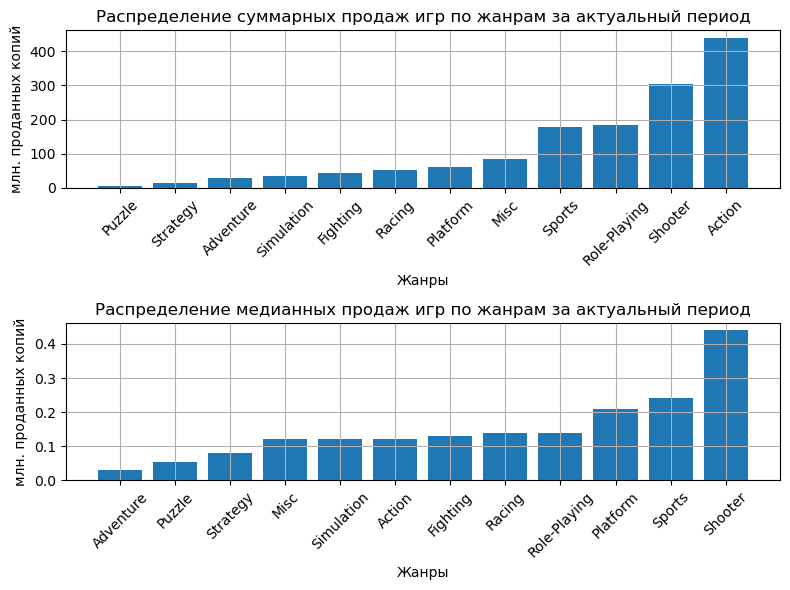

In [45]:
fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(8,6))

genre_sales = games_latest.groupby('genre')['total_sales'].sum().sort_values()
axes[0].bar(genre_sales.index, genre_sales.values)
axes[0].set_xlabel('Жанры')
axes[0].set_ylabel('млн. проданных копий')
axes[0].set_title('Распределение суммарных продаж игр по жанрам за актуальный период')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid()

genre_sales = games_latest.groupby('genre')['total_sales'].median().sort_values()
axes[1].bar(genre_sales.index, genre_sales.values)
axes[1].set_xlabel('Жанры')
axes[1].set_ylabel('млн. проданных копий')
axes[1].set_title('Распределение медианных продаж игр по жанрам за актуальный период')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid()

plt.tight_layout()
plt.show()

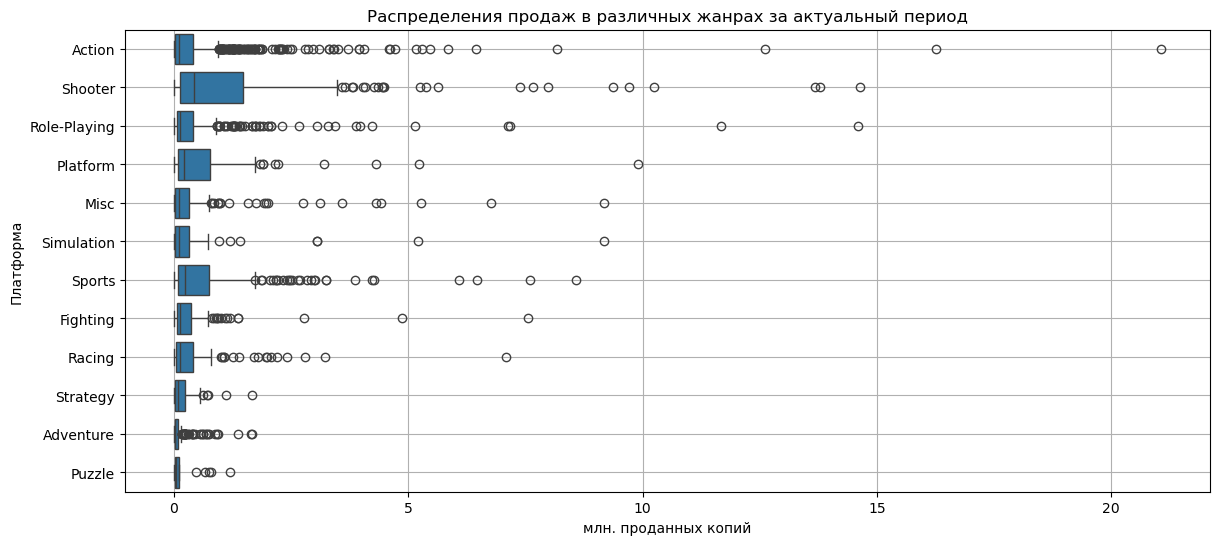

In [46]:
plt.figure(figsize=(14,6))
sns.boxplot(x=games_latest['total_sales'], y=games_latest['genre'])
plt.title('Распределения продаж в различных жанрах за актуальный период')
plt.xlabel('млн. проданных копий')
plt.ylabel('Платформа')
plt.grid()

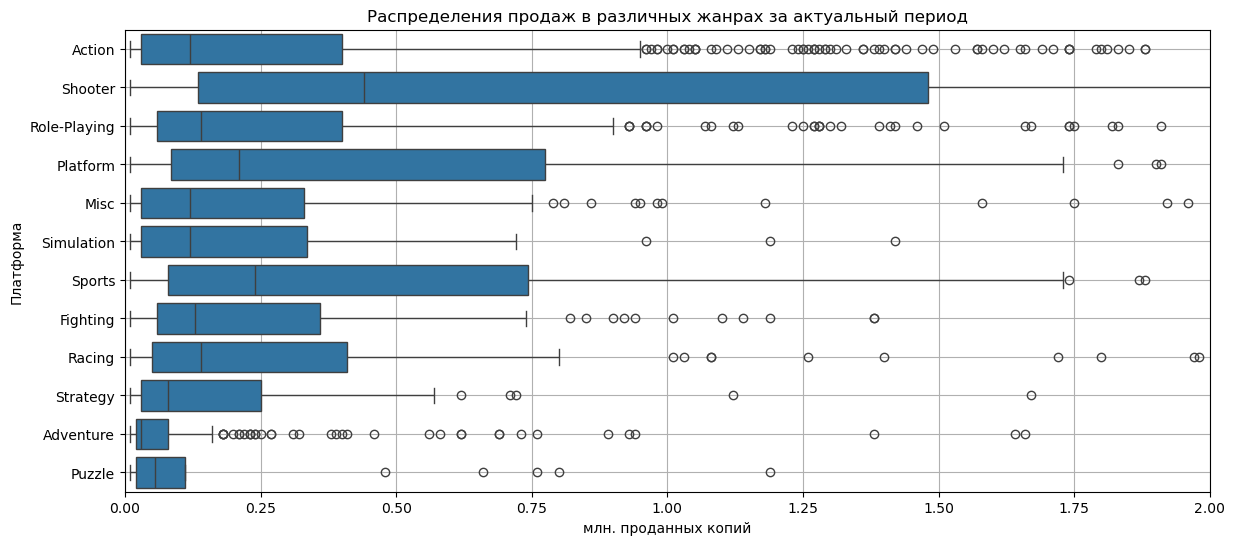

In [47]:
plt.figure(figsize=(14,6))
sns.boxplot(x=games_latest['total_sales'], y=games_latest['genre'])
plt.title('Распределения продаж в различных жанрах за актуальный период')
plt.xlabel('млн. проданных копий')
plt.ylabel('Платформа')
plt.xlim(0, 2)
plt.grid()

По построенным графикам можно составить топ-5 популярных жанров по 3 критериям:
- Суммарное кол-во продаж: `Action`, `Shooter`, `Role-Playing`, `Sports`, `Misc`
- Медианное кол-во продаж: `Shooter`, `Sports`, `Platform`, `Racing`, `Role-Playing`
- Игра с максимальным числом продаж (максимальный выброс на boxplot): `Action`, `Shooter`, `Role-Playing`, `Platform`,  `Misc`

Итого жанры, которые входят в топ-5 по всем критериям: `Shooter`, `Role-Playing`

Самые непопулярные жанры: `Puzzle`, `Adventure`, `Strategy`

### Вывод

Основные выявленные положения:
- Медианное время жизни платформы - 6 лет
- Самые перспективные платформы: `X360`, `PS3`, `PS4`, `XOne`
- У популярной платформы на продажи больше влияеют оценки критиков, чем игроков. У менее популярной платформы оценки пользователей влияют на продажи не меньше оценок критиков. На PC оценки пользователей влияют особенно мало и они более разнообразны
- Самые прибыльные жанры: `Shooter`, `Role-Playing`

## Составление портрета пользователя каждого региона

### Сравнение платформ

Составим рейтинги самых популярных платформ по регионам (NA, EU, JP)

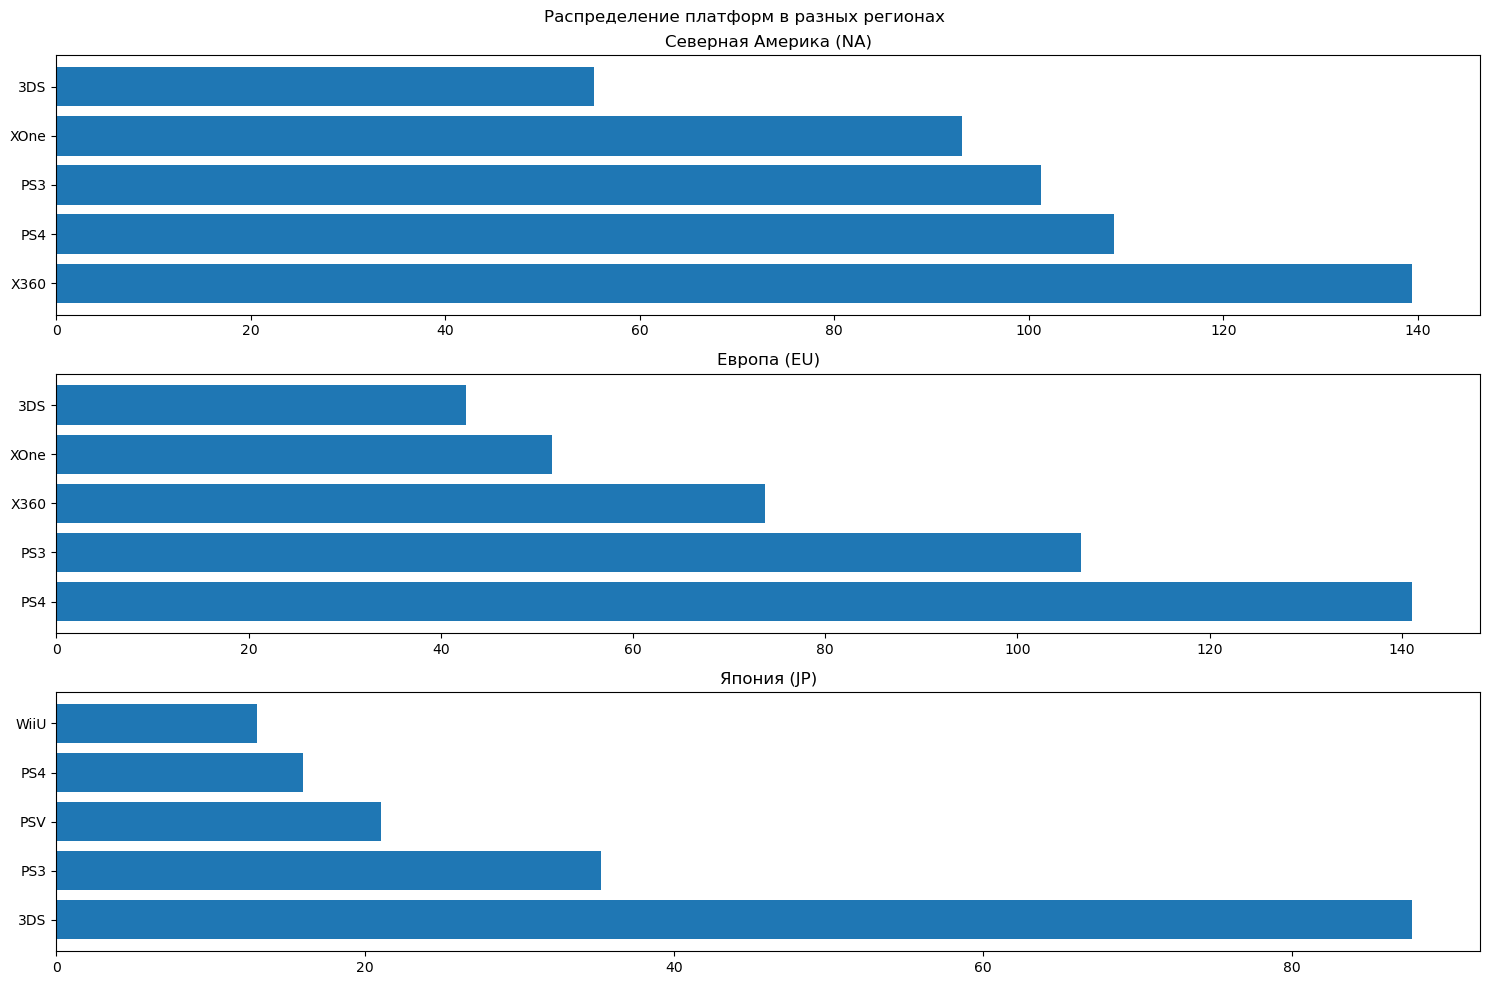

In [48]:
regions_platforms = games_latest.pivot_table(index='platform', aggfunc={'na_sales':'sum', 'eu_sales' : 'sum', 'jp_sales' : 'sum'})
fig, axes = plt.subplots(nrows=3, ncols= 1, figsize=(15,10))

axes[0].barh(regions_platforms.sort_values(by='na_sales', ascending=False).head(5)['na_sales'].index,
             regions_platforms.sort_values(by='na_sales', ascending=False).head(5)['na_sales'].values)
axes[0].set_title('Северная Америка (NA)')

axes[1].barh(regions_platforms.sort_values(by='eu_sales', ascending=False).head(5)['eu_sales'].index,
             regions_platforms.sort_values(by='eu_sales', ascending=False).head(5)['eu_sales'].values)
axes[1].set_title('Европа (EU)')

axes[2].barh(regions_platforms.sort_values(by='jp_sales', ascending=False).head(5)['jp_sales'].index,
             regions_platforms.sort_values(by='jp_sales', ascending=False).head(5)['jp_sales'].values)
axes[2].set_title('Япония (JP)')

plt.suptitle('Распределение платформ в разных регионах')
plt.tight_layout()
plt.show()

По постренным графикам можно сказать, что:
- В Северной Америке и Европе в топ-5 самых популярных платформ входят одни и те же платформы (PS4, PS3, XOne, X360, 3DS), однако в Северной Америке топ-1 X360, а в Европе PS4
- В Японии же по всей видимости консоли Xbox не популярны, они не входят в топ-5. Вместо них пятое и 3 места занимают японские консоли WiiU и PSV. Первое же место с большим отрывом занимает 3DS. Можно сделать вывод, что в Японии более популярны портативные консоли.

### Сравнеение жанров

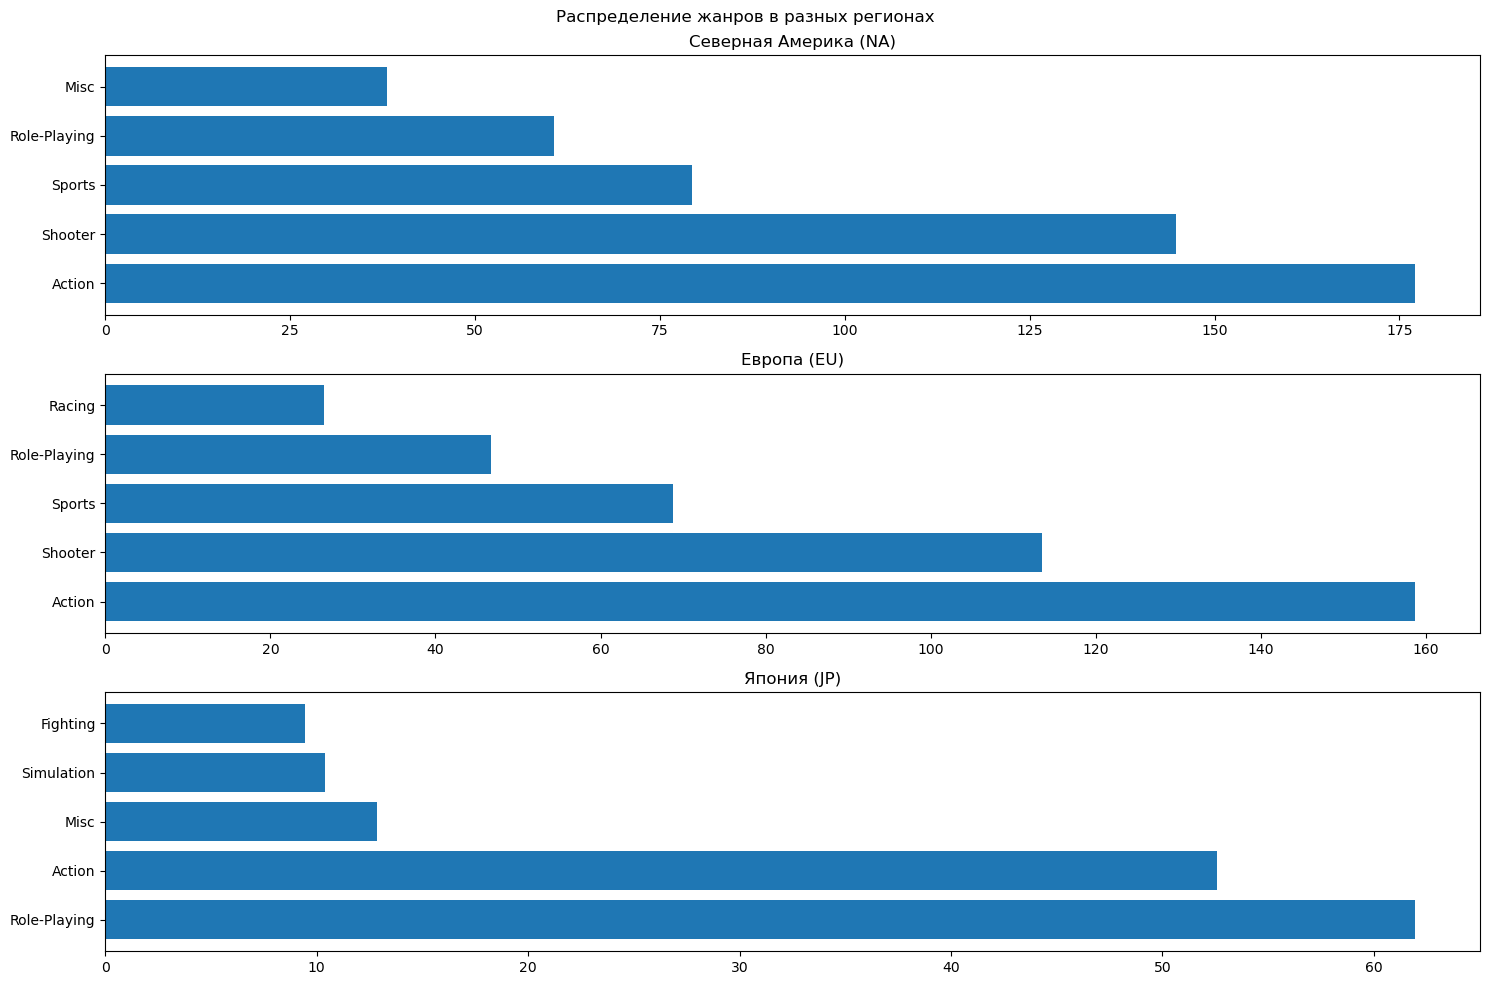

In [49]:
regions_genre = games_latest.pivot_table(index='genre', aggfunc={'na_sales':'sum', 'eu_sales' : 'sum', 'jp_sales' : 'sum'})
regions_genre
fig, axes = plt.subplots(nrows=3, ncols= 1, figsize=(15,10))

axes[0].barh(regions_genre.sort_values(by='na_sales', ascending=False).head(5)['na_sales'].index,
             regions_genre.sort_values(by='na_sales', ascending=False).head(5)['na_sales'].values)
axes[0].set_title('Северная Америка (NA)')

axes[1].barh(regions_genre.sort_values(by='eu_sales', ascending=False).head(5)['eu_sales'].index,
             regions_genre.sort_values(by='eu_sales', ascending=False).head(5)['eu_sales'].values)
axes[1].set_title('Европа (EU)')

axes[2].barh(regions_genre.sort_values(by='jp_sales', ascending=False).head(5)['jp_sales'].index,
             regions_genre.sort_values(by='jp_sales', ascending=False).head(5)['jp_sales'].values)
axes[2].set_title('Япония (JP)')

plt.suptitle('Распределение жанров в разных регионах')
plt.tight_layout()
plt.show()

- В Северной Америке и Европе топ-5 популярных жанров практически идентичен, разница лишь в том, что в Северной Америке топ-5 - Misc, а в Европе - Racing
- В Японии первые два места с большим отрывом занимают Role-Playing и Action

### Анализ возрастного рейтинга ESRB

In [50]:
games_latest['rating'].unique()

array(['M', nan, 'E', 'E10+', 'T'], dtype=object)

Типы оценок:
- E - Everyone (для всех)
- E10+ - Everyone 10 and older (для всех 10 лет и больше)
- T - Teen (подросткам)
- M - Mature (для взрослых)

Пропуски заменим на `RP` - Rating Pending (рейтинг ожидается)

In [51]:
games_latest.loc[:,'rating'] = games_latest.loc[:,'rating'].fillna('RP')

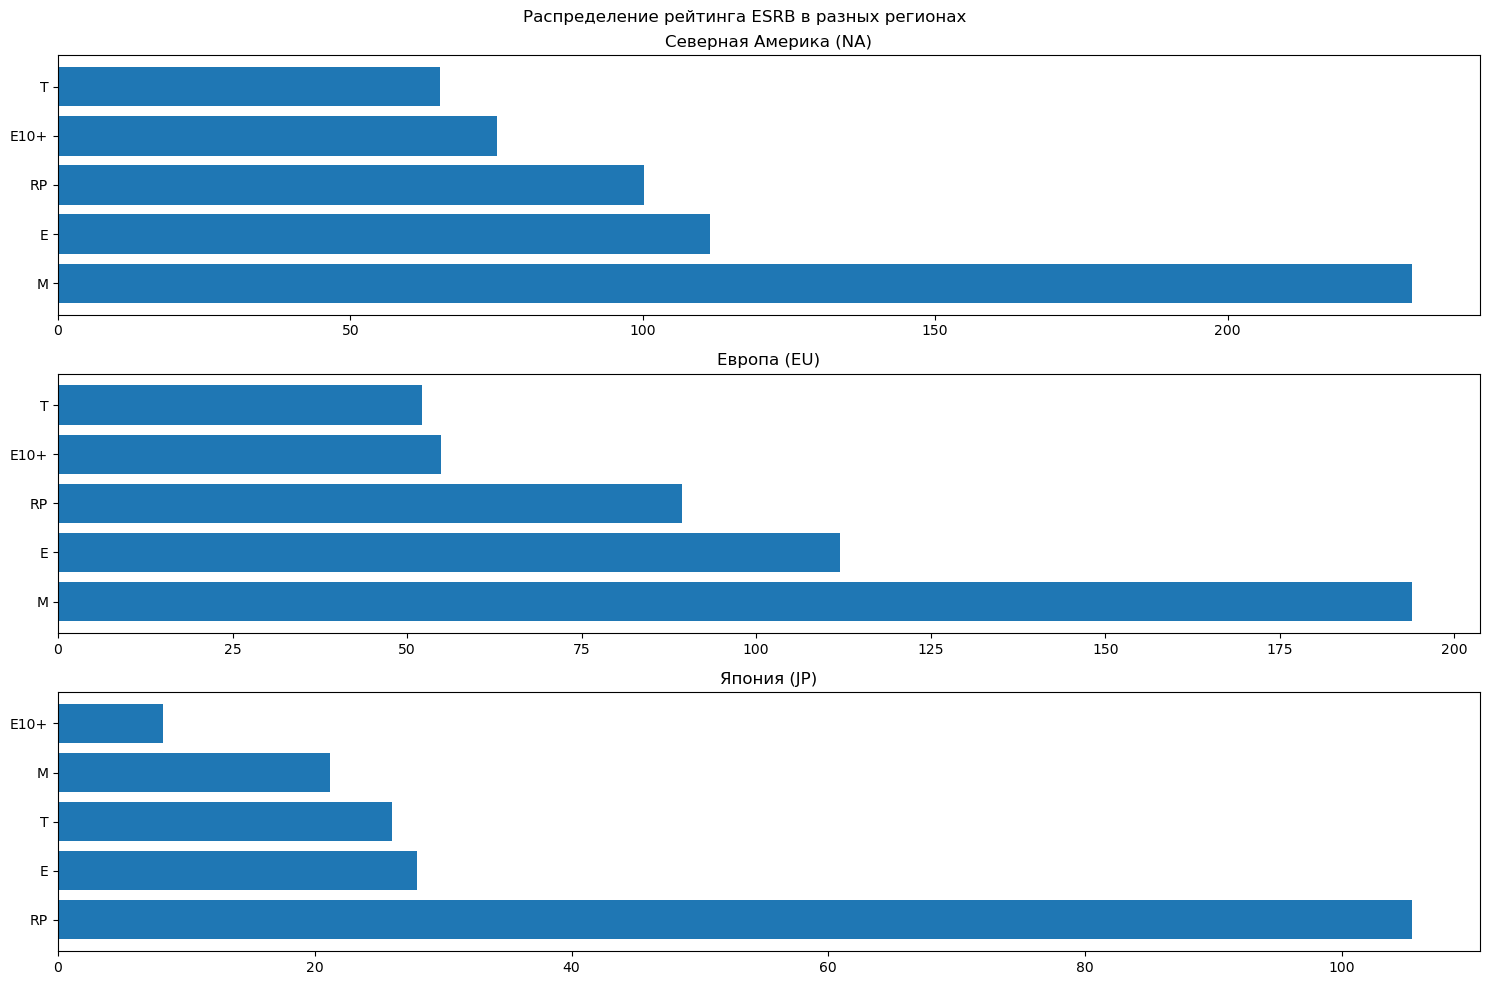

In [52]:
regions_rating = games_latest.pivot_table(index='rating', aggfunc={'na_sales':'sum', 'eu_sales' : 'sum', 'jp_sales' : 'sum'})
fig, axes = plt.subplots(nrows=3, ncols= 1, figsize=(15,10))

axes[0].barh(regions_rating.sort_values(by='na_sales', ascending=False).head(5)['na_sales'].index,
             regions_rating.sort_values(by='na_sales', ascending=False).head(5)['na_sales'].values)
axes[0].set_title('Северная Америка (NA)')

axes[1].barh(regions_rating.sort_values(by='eu_sales', ascending=False).head(5)['eu_sales'].index,
             regions_rating.sort_values(by='eu_sales', ascending=False).head(5)['eu_sales'].values)
axes[1].set_title('Европа (EU)')

axes[2].barh(regions_rating.sort_values(by='jp_sales', ascending=False).head(5)['jp_sales'].index,
             regions_rating.sort_values(by='jp_sales', ascending=False).head(5)['jp_sales'].values)
axes[2].set_title('Япония (JP)')

plt.suptitle('Распределение рейтинга ESRB в разных регионах')
plt.tight_layout()
plt.show()

- В Северной Америке и Европе топ-5 одинаковый, самый популярный рейтинг "для взрослых", самый не популярный "для подростков"
- В Япопнии самый популярный рейтинг "для всех", самый не популярный "для всех больше 10 лет"
- В Японии очень много игр без рейтинга ESRB, что скорее всего вызвано тем, что ESRB - американская организация

### Вывод

Распределение продаж в зависимости от различных факторов в Северной Америке и Европе очень похожи:
- Самые популярные платформы PS3, PS4, X360
- Самые популярные жанры Action, Shooter
- Самый популярный рейтинг ESRB "M" (для взрослых)

Япония же сильно отличается по всем факторам:
- Самая популярная консоль с большим отрывом 3DS
- Самые популярные жанры Role-Playing, Action
- Самый популярный рейтинг ESRB "E" (для всех) (много игр вообще не имеют рейтинга ESRB)

## Проверка гипотез

### Гипотеза 1

Средние пользовательские рейтинги платформ _Xbox One_ и _PC_ одинаковые.

Нулевая гипотеза:
$H_0:\mu_{\text{xbox}}=\mu_{\text{pc}}$

Альтернативная гипотеза:
$H_1:\mu_{\text{xbox}}\ne\mu_{\text{pc}}$

Возьмём $\alpha=0.01$

В данной гипотезе мы имеем дело со сравнением средних двух независимых генеральных совокупностей $\implies$ следует использовать метод `st.ttest_ind()`

In [53]:
alpha = 0.01
res = st.ttest_ind(games_latest.dropna(subset=['user_score']).query('platform == "XOne"')['user_score'], games_latest.dropna(subset=['user_score']).query('platform == "PC"')['user_score'])
print(f'p-value: {res.pvalue}')
if res.pvalue < alpha:
    print('Отвергаем нулевую гипотез. Средние пользовательские рейтинги платформ Xbox One и PC НЕ одинаковые.')
else:
    print('Нет оснований отвергнуть нулевую гипотезу. Средние пользовательские рейтинги платформ Xbox One и PC одинаковые.')
print('Средняя пользовательская оценка платформы Xbox One ', games_latest.query('platform == "XOne"')['user_score'].mean())
print('Средняя пользовательская оценка платформы PC ', games_latest.query('platform == "PC"')['user_score'].mean())

p-value: 0.5112133814834332
Нет оснований отвергнуть нулевую гипотезу. Средние пользовательские рейтинги платформ Xbox One и PC одинаковые.
Средняя пользовательская оценка платформы Xbox One  6.521428571428572
Средняя пользовательская оценка платформы PC  6.418536585365853


### Гипотеза 2

Средние пользовательские рейтинги жанров _Action_ (англ. «действие», экшен-игры) и _Sports_ (англ. «спортивные соревнования») разные.

Нулевая гипотеза:
$H_0:\mu_{\text{sport}}=\mu_{\text{action}}$

Альтернативная гипотеза:
$H_0:\mu_{\text{sport}}\ne\mu_{\text{action}}$

Возьмём $\alpha=0.01$

В данной гипотезе мы имеем дело со сравнением средних двух независимых генеральных совокупностей $\implies$ следует использовать метод `st.ttest_ind()`

In [54]:
alpha = 0.01
res = st.ttest_ind(games_latest.dropna(subset=['user_score']).query('genre == "Action"')['user_score'], games_latest.dropna(subset=['user_score']).query('genre == "Sports"')['user_score'])
print(f'p-value: {res.pvalue}')
if res.pvalue < alpha:
    print('Отвергаем нулевую гипотез. Средние пользовательские рейтинги жанров Action и Sport НЕ одинаковые.')
else:
    print('Нет оснований отвергнуть нулевую гипотезу. Средние пользовательские рейтинги жанров Action и Sport одинаковые.')
print('Средняя пользовательская оценка жанра Action: ', games_latest.query('genre == "Action"')['user_score'].mean())
print('Средняя пользовательская оценка жанра Sports: ', games_latest.query('genre == "Sports"')['user_score'].mean())

p-value: 5.656012493403273e-26
Отвергаем нулевую гипотез. Средние пользовательские рейтинги жанров Action и Sport НЕ одинаковые.
Средняя пользовательская оценка жанра Action:  6.826679462571977
Средняя пользовательская оценка жанра Sports:  5.455440414507772


## Общий вывод

По полученным данным была проведена следующая работа:

Предобработка данных:
- Названия столбцов приведены к нижнему регистру
- В столбце `user_score` значения `tbd` ("To Be Determined") были заменены на `NaN`
- Тип данных в столбце `user_score` изменён на `float`
- Удалены строки с пропусками в столбцах `name` и `genre`
- Обработана неявные дубликаты в столбце `name`
- Создан столбец `total_sales` с суммарными продажами во всех регионах

Исследовательский анализ данных:
- Медианное время жизни платформы - 6 лет
- Самые перспективные платформы: `X360`, `PS3`, `PS4`, `XOne`
- У популярной платформы на продажи больше влияеют оценки критиков, чем игроков. У менее популярной платформы оценки пользователей влияют на продажи не меньше оценок критиков. На PC оценки пользователей влияют особенно мало и они более разнообразны
- Самые прибыльные жанры: `Shooter`, `Role-Playing`

Составление портрета пользователя каждого региона:

- Распределение продаж в зависимости от различных факторов в Северной Америке и Европе очень похожи:
  - Самые популярные платформы PS3, PS4, X360
  - Самые популярные жанры Action, Shooter
  - Самый популярный рейтинг ESRB "M" (для взрослых)
- Япония же сильно отличается по всем факторам:
  - Самая популярная консоль с большим отрывом 3DS
  - Самые популярные жанры Role-Playing, Action
  - Самый популярный рейтинг ESRB "E" (для всех) (много игр вообще не имеют рейтинга ESRB)

Проверка гипотез:

Были проверены 2 гипотезы:
- Средние пользовательские рейтинги платформ Xbox One и PC одинаковые
- Средние пользовательские рейтинги жанров Action и Sport не одинаковые

Рекомендации заказчику по проведению кампании в следующем году:
- Ориентироваться на консоли Sony и Microsoft (PS4, PS3, XOne, X360)
- Ориентироваться больше на оценки критиков, нежели на оценки пользователей
- Ориентироваться на жанры `Shooter`, `Role-Playing`
- Помнить о региональных отличиях Японии от Северной Америки и Европы